#### Generate Simluation

In [1]:
import numpy as np
import scanpy as sc
import seaborn as sns
import sys

sys.path.append('../simulator')
from hiererchical_simulator import get_data_and_visualize

import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

Parsing xml tree file...
Generating alpha matrix...


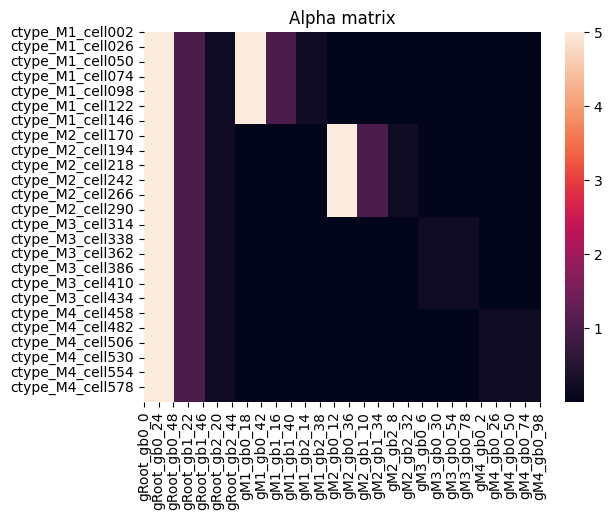

Sampling p's from Dirichlet distribution...
Sampling cell total UMIs from logNormal distribution...
M1 10 0.3
M2 10 0.3
M3 10 0.3
M4 10 0.3
Sampling cells from multinomial distribution...


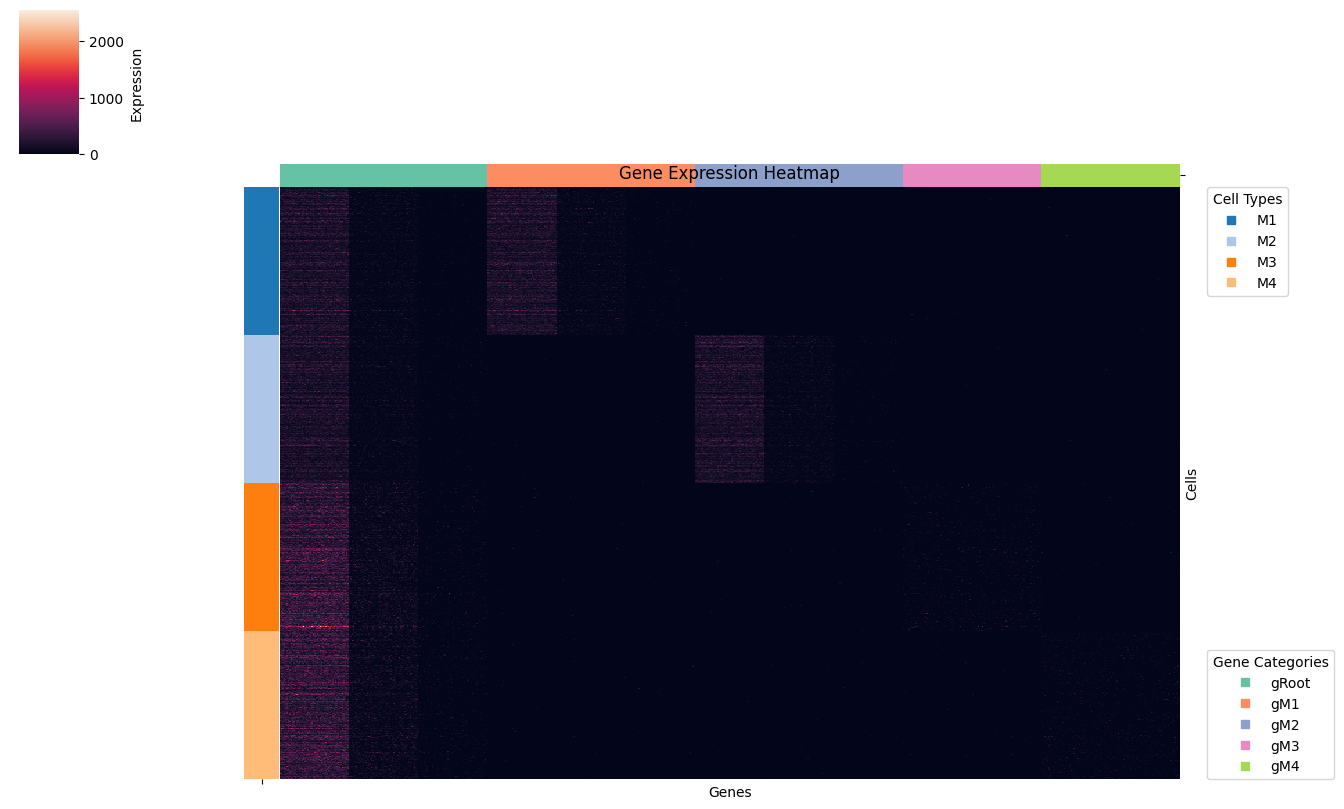

Saving anndata to: ../sim_data/adata/adata_100.h5ad


In [2]:
data_df, adata = get_data_and_visualize(tree_id=100)

sc.pp.normalize_total(adata, target_sum=1e4)

#### Compute CME

In [12]:
sys.path.append('../CME')
from CME_func import CME

<Axes: >

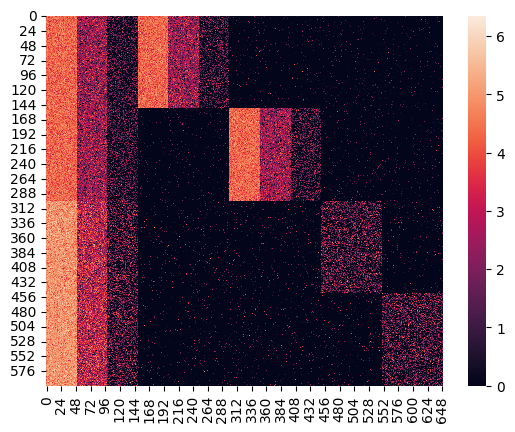

In [37]:
sns.heatmap(np.log(adata.X+1))

In [29]:
import importlib
import sys
importlib.reload(sys.modules[CME.__module__])
from CME_func import CME

/home/hxin/.local/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


<Axes: >

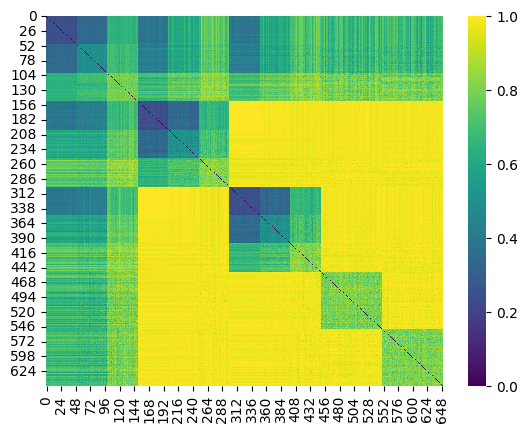

In [33]:
cme = CME(adata.X.T, normalize=True)
sns.heatmap(cme, cmap='viridis')

<Axes: >

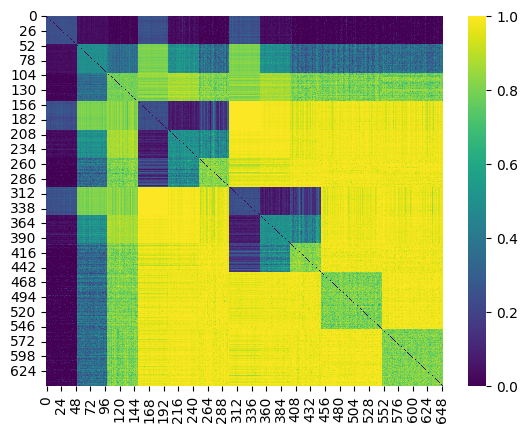

In [32]:
cme = CME(adata.X.T, normalize=False)
sns.heatmap(cme, cmap='viridis')

#### Test Normalize

In [5]:
X=adata.X.T

In [19]:
np.median(X[55][np.nonzero(X[55])])

13.842722

In [20]:
median_ary = np.apply_along_axis(lambda v: np.median(v[np.nonzero(v)]), 1, X)

In [23]:
X_normed = X / median_ary[:, None]

650